Pneumonia Detection using Deep Learning

In [1]:
import sys
import os

sys.path.append('../src')

print("✓ Path configured")
print(f"Current directory: {os.getcwd()}")
print(f"Python path includes: {sys.path[-1]}")

✓ Path configured
Current directory: E:\Projects\Medical Image Classification for Pneumonia Detection\notebooks
Python path includes: ../src


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from config import Config
from dataset import get_data_loaders, get_data_transforms
from model import get_model
from train import train_model
from evaluate import run_evaluation
from inference import PneumoniaPredictor, predict_single_image
from utils import set_seed, plot_training_history

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

set_seed(Config.SEED)

print("✓ All imports successful!")
print(f"✓ Using device: {Config.DEVICE}")

✓ All imports successful!
✓ Using device: cuda


Data Exploration

In [6]:
# Print configuration
Config.print_config()

Configuration Parameters
BASE_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection
DATA_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray
PROCESSED_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\processed
MODEL_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\models\saved_models
RESULTS_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\results
PLOTS_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\results\plots
METRICS_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\results\metrics
TRAIN_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\train
VAL_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\val
TEST_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\test
MODEL_NAME: efficientnet_b0
NUM_CLASSES: 2
P

In [8]:
# Load datasets
train_loader, val_loader, test_loader = get_data_loaders()


Loading Datasets
Found 5216 images in E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\train
Classes: ['NORMAL', 'PNEUMONIA']
Class distribution: [1341 3875]
Found 16 images in E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\val
Classes: ['NORMAL', 'PNEUMONIA']
Class distribution: [8 8]
Found 624 images in E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\test
Classes: ['NORMAL', 'PNEUMONIA']
Class distribution: [234 390]

Train batches: 326
Validation batches: 1
Test batches: 39



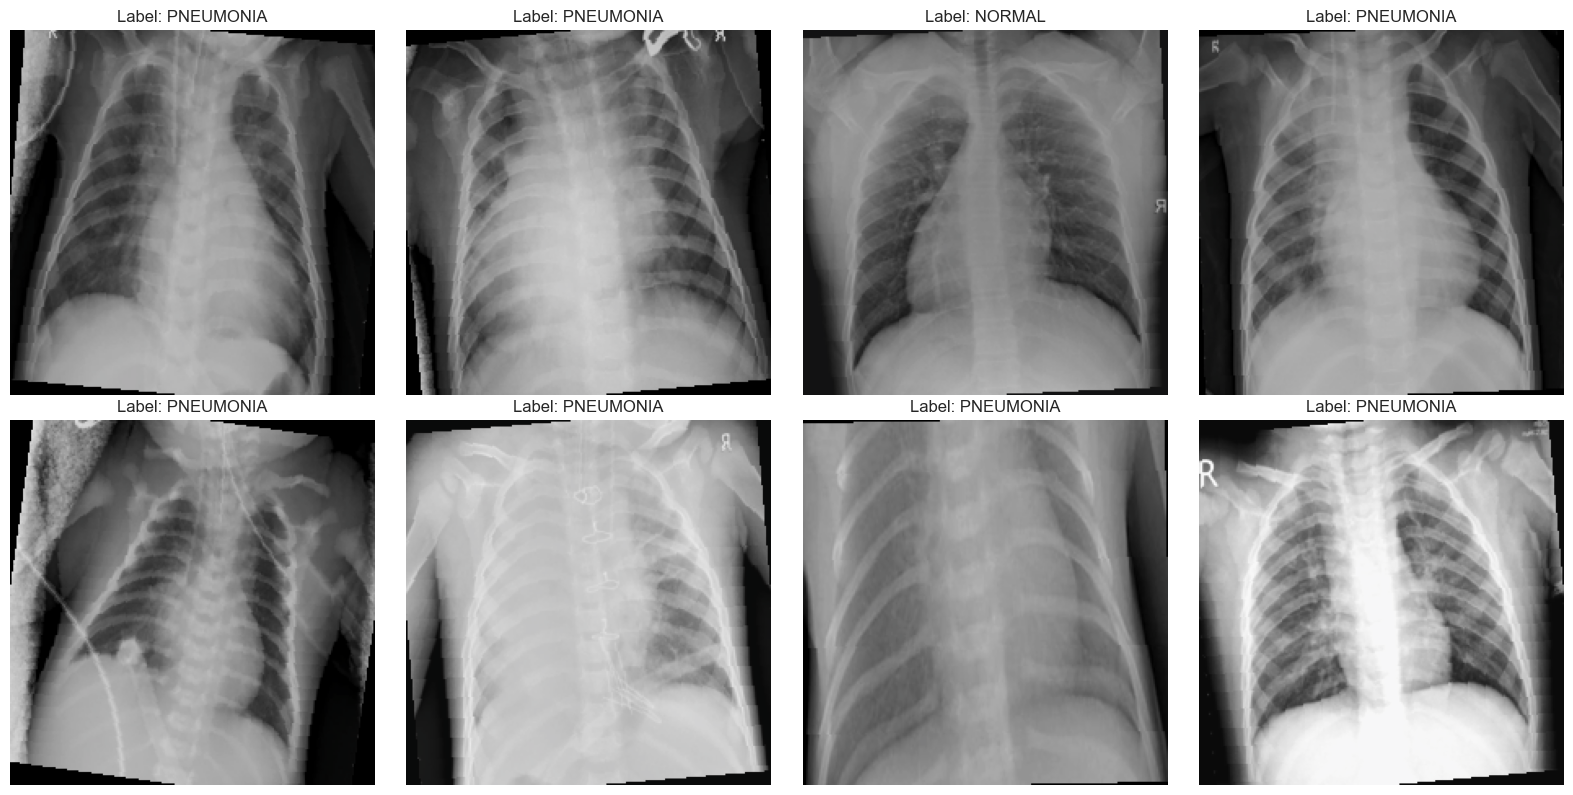

In [10]:
# Visualize sample images from training set
def visualize_samples(dataloader, num_samples=8):
    """Visualize sample images from dataloader"""
    images, labels = next(iter(dataloader))
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for i in range(min(num_samples, len(images))):
        # Denormalize image
        img = images[i].numpy().transpose(1, 2, 0)
        mean = np.array(Config.MEAN)
        std = np.array(Config.STD)
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Plot
        axes[i].imshow(img)
        axes[i].set_title(f'Label: {Config.CLASS_NAMES[labels[i]]}', fontsize=12)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('../results/plots/sample_training_images.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_samples(train_loader)


Training Class Distribution:
----------------------------------------
PNEUMONIA: 3875 (74.29%)
NORMAL: 1341 (25.71%)


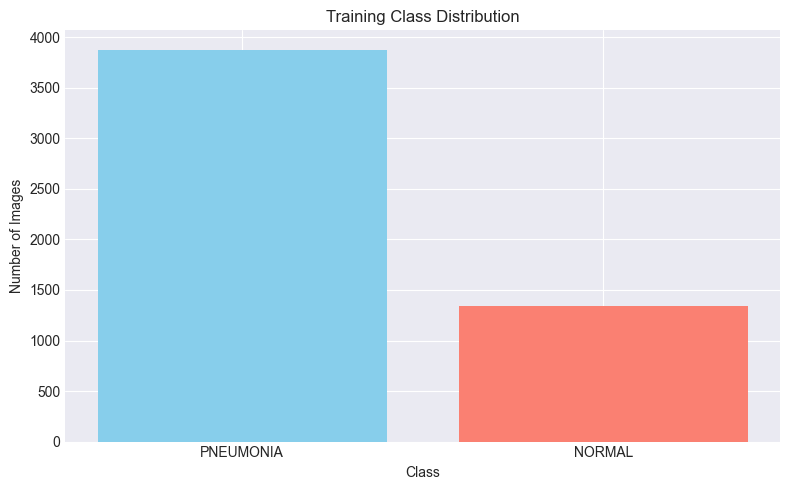


Validation Class Distribution:
----------------------------------------
NORMAL: 8 (50.00%)
PNEUMONIA: 8 (50.00%)


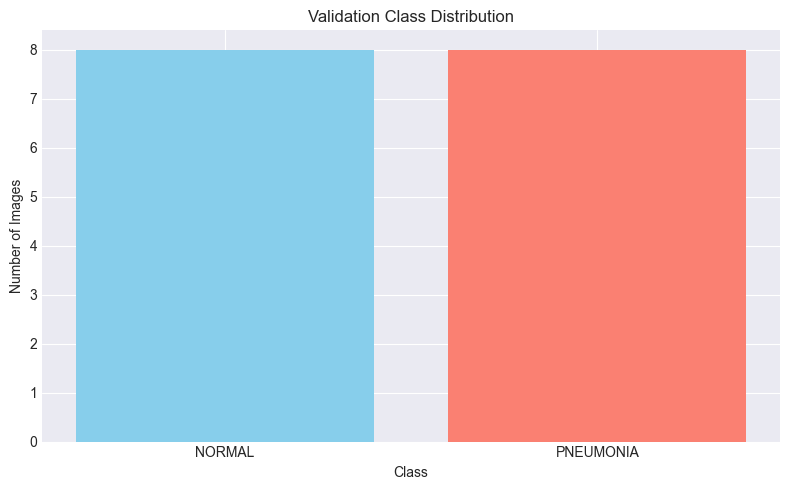


Test Class Distribution:
----------------------------------------
NORMAL: 234 (37.50%)
PNEUMONIA: 390 (62.50%)


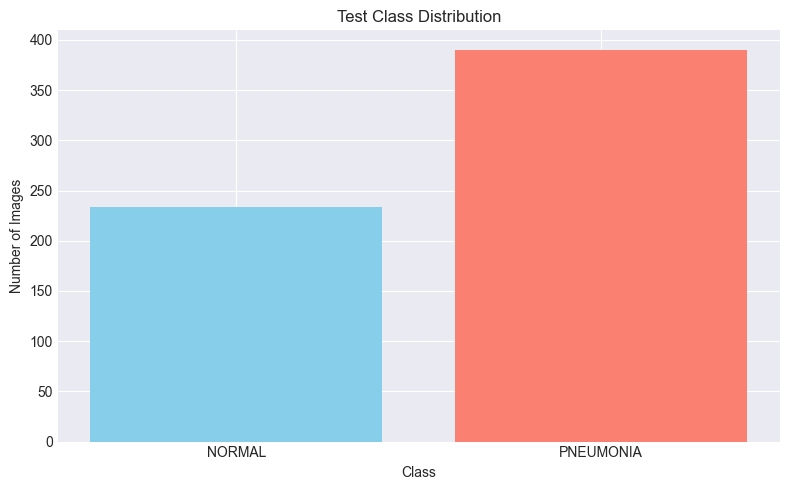

In [12]:
# Check class distribution
from collections import Counter

def check_class_distribution(loader, dataset_name):
    """Check class distribution in dataset"""
    all_labels = []
    for _, labels in loader:
        all_labels.extend(labels.numpy())
    
    counter = Counter(all_labels)
    
    print(f"\n{dataset_name} Class Distribution:")
    print("-" * 40)
    for class_idx, count in counter.items():
        class_name = Config.CLASS_NAMES[class_idx]
        percentage = (count / len(all_labels)) * 100
        print(f"{class_name}: {count} ({percentage:.2f}%)")
    
    # Plot
    plt.figure(figsize=(8, 5))
    classes = [Config.CLASS_NAMES[i] for i in counter.keys()]
    counts = list(counter.values())
    
    plt.bar(classes, counts, color=['skyblue', 'salmon'])
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.title(f'{dataset_name} Class Distribution')
    plt.tight_layout()
    plt.savefig(f'../results/plots/{dataset_name.lower()}_distribution.png', 
                dpi=300, bbox_inches='tight')
    plt.show()

check_class_distribution(train_loader, 'Training')
check_class_distribution(val_loader, 'Validation')
check_class_distribution(test_loader, 'Test')

Model Architecture

In [15]:
# Create model
model = get_model(pretrained=Config.PRETRAINED)


Model Information
Model: EfficientNet-B0
Total parameters: 4,664,446
Trainable parameters: 4,664,446
Device: cuda



In [17]:
# Printing model summary
print("\nModel Architecture:")
print("=" * 60)
print(model)
print("=" * 60)


Model Architecture:
PneumoniaClassifier(
  (model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
        

Model Training

Starting training...
Configuration Parameters
BASE_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection
DATA_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray
PROCESSED_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\processed
MODEL_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\models\saved_models
RESULTS_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\results
PLOTS_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\results\plots
METRICS_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\results\metrics
TRAIN_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\train
VAL_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\val
TEST_DIR: E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\test
MODEL_NAME: efficientne


Train Loss: 0.1568 | Train Acc: 94.19%
Val Loss: 0.2751 | Val Acc: 87.50%
Epoch Time: 133.34s
Learning Rate: 0.001000
Model saved to E:\Projects\Medical Image Classification for Pneumonia Detection\models\saved_models\best_model.pth
✓ New best model saved! (Val Acc: 87.50%)

Epoch 2/25
--------------------------------------------------



Train Loss: 0.0986 | Train Acc: 96.88%
Val Loss: 0.0615 | Val Acc: 100.00%
Epoch Time: 129.83s
Learning Rate: 0.001000
Model saved to E:\Projects\Medical Image Classification for Pneumonia Detection\models\saved_models\best_model.pth
✓ New best model saved! (Val Acc: 100.00%)

Epoch 3/25
--------------------------------------------------



Train Loss: 0.0817 | Train Acc: 96.99%
Val Loss: 0.1725 | Val Acc: 93.75%
Epoch Time: 129.83s
Learning Rate: 0.001000

EarlyStopping counter: 1/5
Epoch 4/25
--------------------------------------------------



Train Loss: 0.0676 | Train Acc: 97.30%
Val Loss: 0.1905 | Val Acc: 100.00%
Epoch Time: 130.38s
Learning Rate: 0.001000

EarlyStopping counter: 2/5
Epoch 5/25
--------------------------------------------------


...


Train Loss: 0.0657 | Train Acc: 97.70%
Val Loss: 0.2231 | Val Acc: 93.75%
Epoch Time: 131.49s
Learning Rate: 0.001000

EarlyStopping counter: 1/5
Epoch 8/25
--------------------------------------------------



Train Loss: 0.0548 | Train Acc: 98.03%
Val Loss: 0.1259 | Val Acc: 100.00%
Epoch Time: 128.80s
Learning Rate: 0.001000

EarlyStopping counter: 2/5
Epoch 9/25
--------------------------------------------------



Train Loss: 0.0650 | Train Acc: 97.62%
Val Loss: 0.3618 | Val Acc: 68.75%
Epoch Time: 128.03s
Learning Rate: 0.001000

EarlyStopping counter: 3/5
Epoch 10/25
--------------------------------------------------



Train Loss: 0.0615 | Train Acc: 97.76%
Val Loss: 0.1191 | Val Acc: 93.75%
Epoch Time: 130.15s
Learning Rate: 0.000500

EarlyStopping counter: 4/5
Epoch 11/25
--------------------------------------------------



Train Loss: 0.0305 | Train Acc: 98.93%
Val Loss: 0.1089 | Val Acc: 100.00%
Epoch Time: 129.81s
Learning Rate: 0.000500

EarlyStopping counter: 5/5
Early stopping triggered!
Training Complete!
Total Time: 25.16 minutes
Best Validation Accuracy: 100.00%

Training history plot saved to E:\Projects\Medical Image Classification for Pneumonia Detection\results\plots\training_history.png


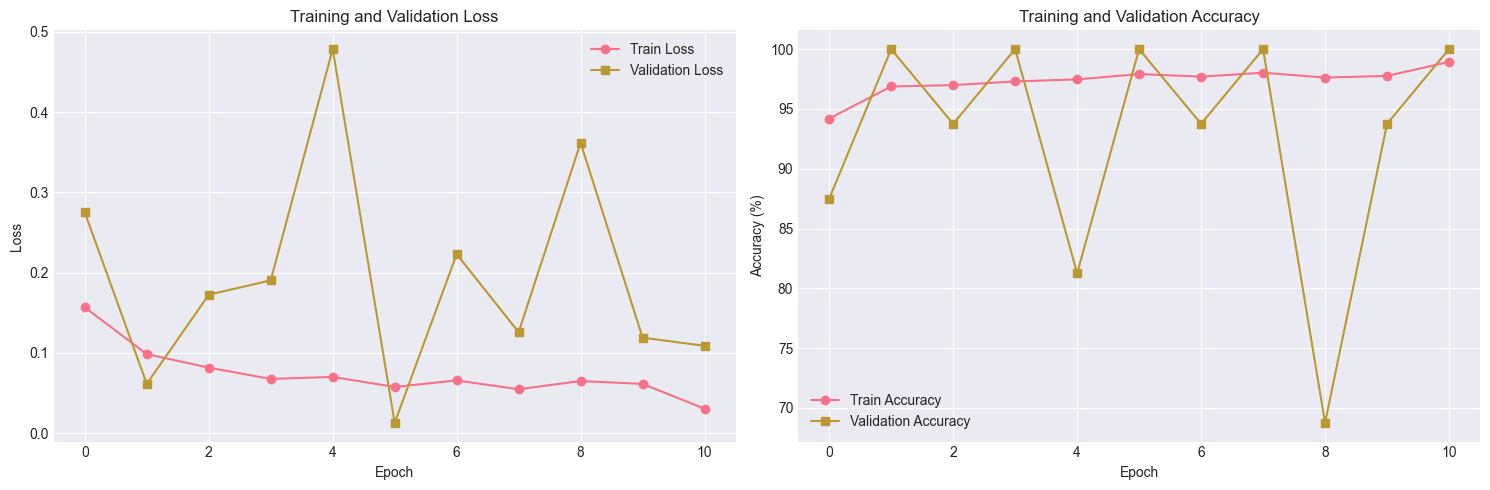

Metrics saved to E:\Projects\Medical Image Classification for Pneumonia Detection\results\metrics\training_history.json


In [20]:
# Train the model
print("Starting training...")
model, history = train_model(
    num_epochs=Config.NUM_EPOCHS,
    batch_size=Config.BATCH_SIZE,
    learning_rate=Config.LEARNING_RATE
)

Training history plot saved to ../results/plots/training_history.png


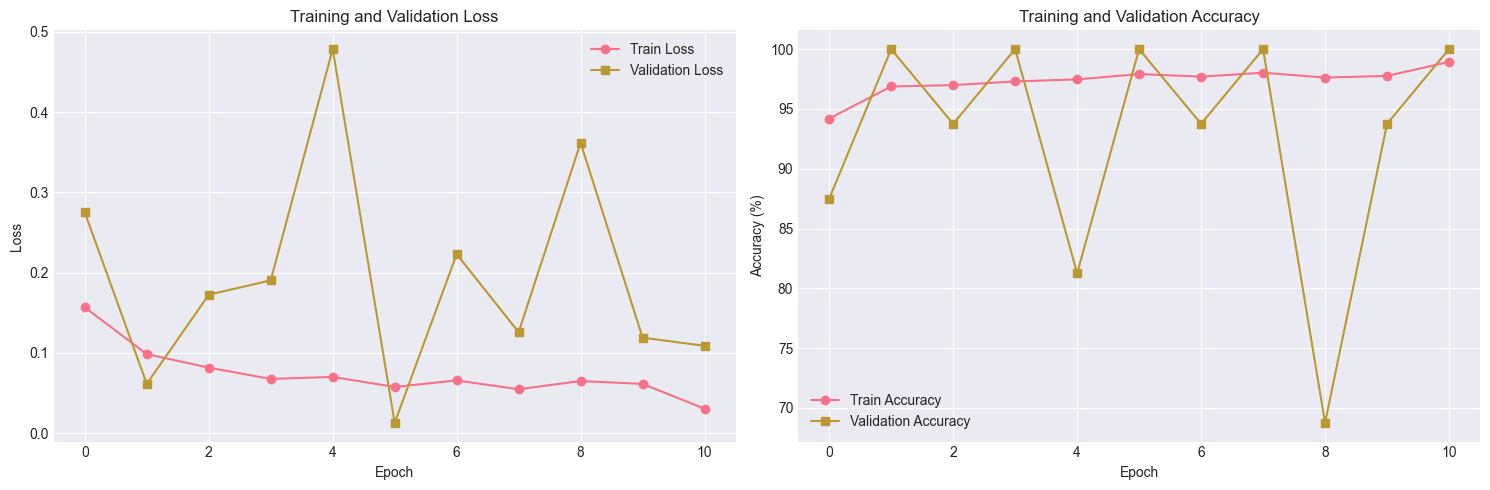

In [22]:
# Plot training history
plot_training_history(
    history,
    save_path='../results/plots/training_history.png'
)

Model Evaluation

Evaluating on test set...

PNEUMONIA DETECTION MODEL EVALUATION

Loading Datasets
Found 5216 images in E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\train
Classes: ['NORMAL', 'PNEUMONIA']
Class distribution: [1341 3875]
Found 16 images in E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\val
Classes: ['NORMAL', 'PNEUMONIA']
Class distribution: [8 8]
Found 624 images in E:\Projects\Medical Image Classification for Pneumonia Detection\data\raw\chest_xray\test
Classes: ['NORMAL', 'PNEUMONIA']
Class distribution: [234 390]

Train batches: 326
Validation batches: 1
Test batches: 39


Model Information
Model: EfficientNet-B0
Total parameters: 4,664,446
Trainable parameters: 4,664,446
Device: cuda

Model loaded from E:\Projects\Medical Image Classification for Pneumonia Detection\models\saved_models\best_model.pth (Epoch 2, Best Acc: 100.0000)

Evaluating model...


Testing: 100%|█████████████████████████████████████████████████████████████████████████| 39/39 [00:25<00:00,  1.51it/s]



EVALUATION METRICS
Accuracy:  90.06%
Precision: 88.86%
Recall:    96.15%
F1-Score:  92.36%

Per-Class Metrics:
------------------------------------------------------------
NORMAL:
  Precision: 92.57%
  Recall:    79.91%
  F1-Score:  85.78%
PNEUMONIA:
  Precision: 88.86%
  Recall:    96.15%
  F1-Score:  92.36%

Metrics saved to E:\Projects\Medical Image Classification for Pneumonia Detection\results\metrics\test_metrics.json
Confusion matrix saved to E:\Projects\Medical Image Classification for Pneumonia Detection\results\plots\confusion_matrix.png


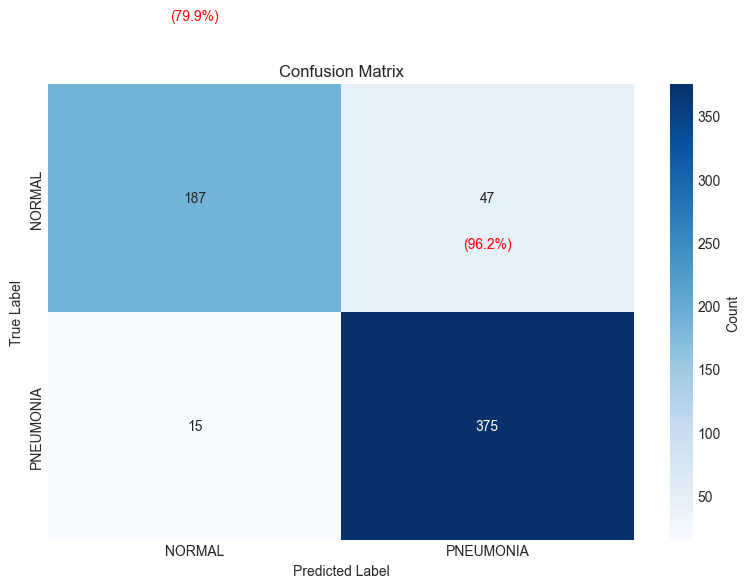

ROC curve saved to E:\Projects\Medical Image Classification for Pneumonia Detection\results\plots\roc_curve.png


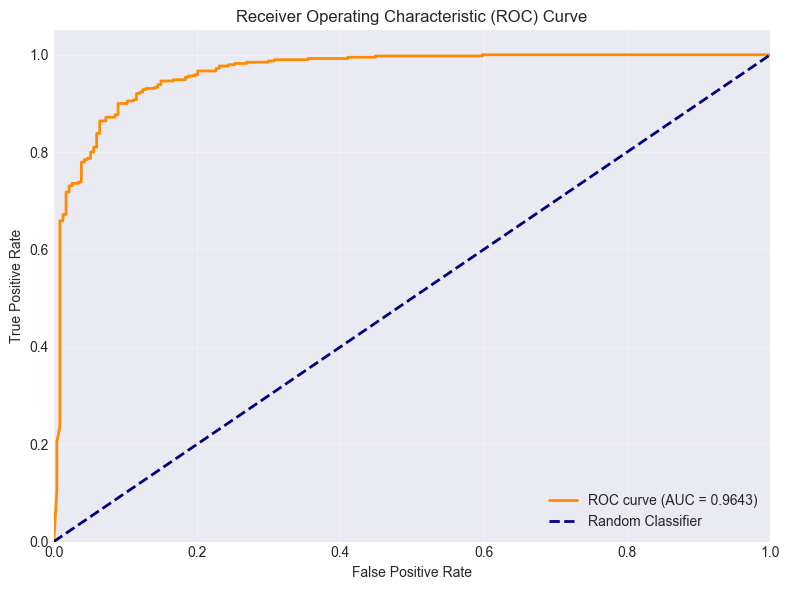

ROC-AUC Score: 0.9643
Classification report saved to E:\Projects\Medical Image Classification for Pneumonia Detection\results\metrics\classification_report.txt

              precision    recall  f1-score   support

      NORMAL     0.9257    0.7991    0.8578       234
   PNEUMONIA     0.8886    0.9615    0.9236       390

    accuracy                         0.9006       624
   macro avg     0.9072    0.8803    0.8907       624
weighted avg     0.9025    0.9006    0.8990       624

Predictions visualization saved to E:\Projects\Medical Image Classification for Pneumonia Detection\results\plots\sample_predictions.png


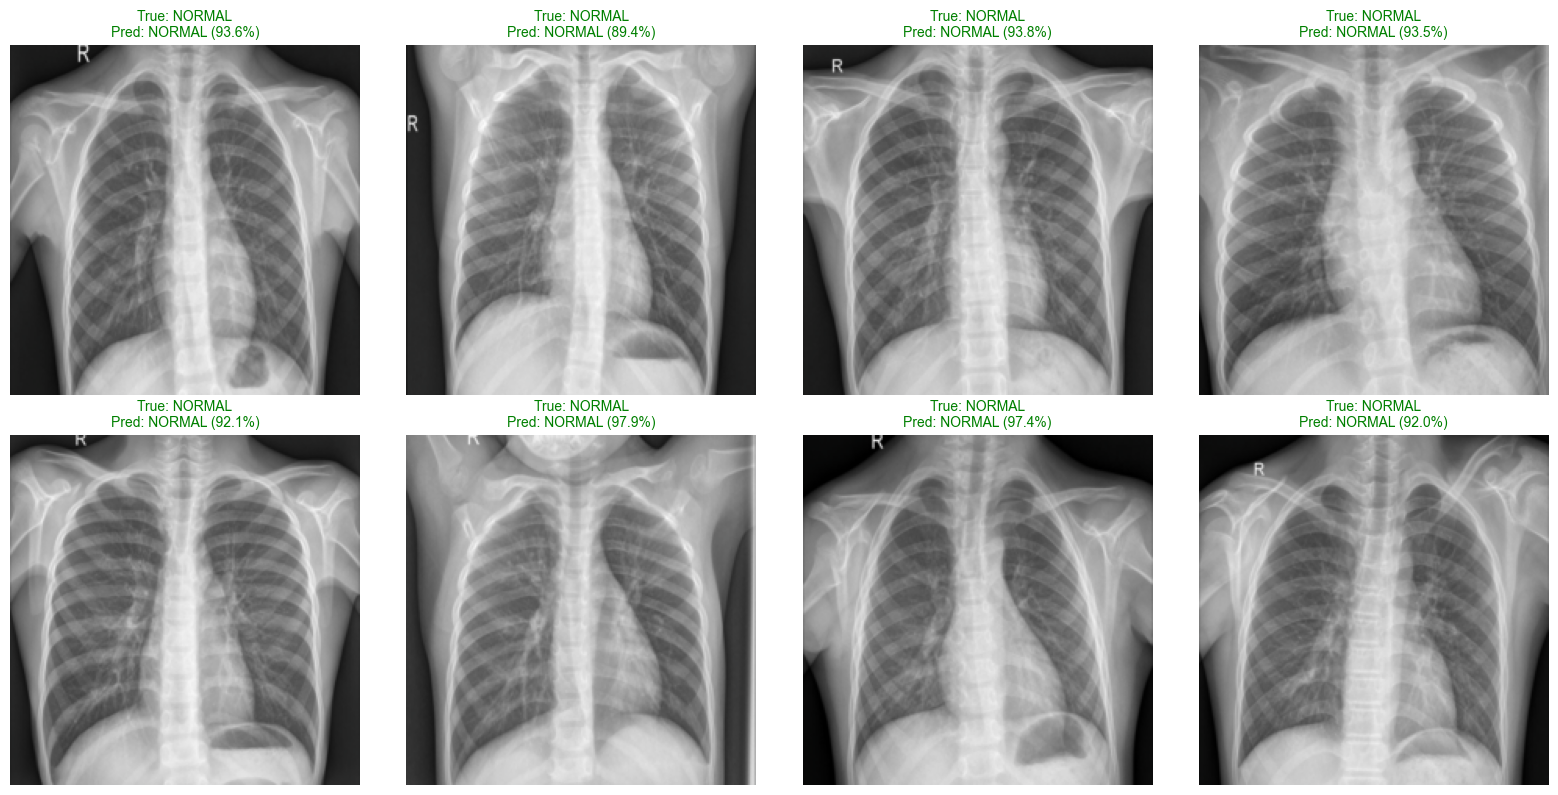


EVALUATION COMPLETE!
Results saved to: E:\Projects\Medical Image Classification for Pneumonia Detection\results



In [25]:
# Run comprehensive evaluation
print("Evaluating on test set...")
metrics, y_true, y_pred, y_scores = run_evaluation()

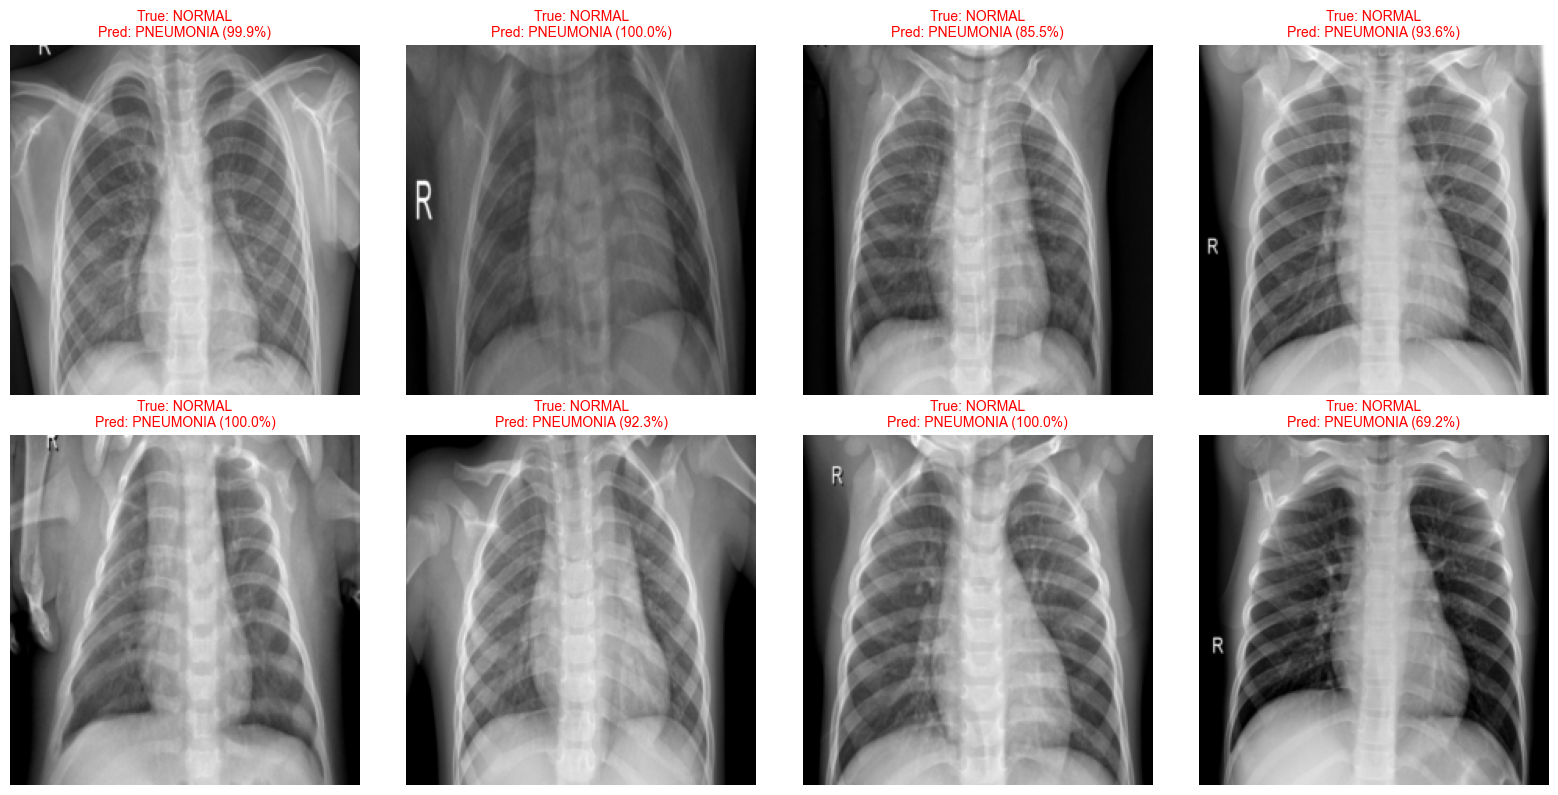

In [27]:
# Additional analysis - showing misclassified samples
def show_misclassified(model, test_loader, num_samples=8):
    """Show misclassified samples"""
    model.eval()
    
    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []
    misclassified_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
            outputs = model(images)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            # Find misclassified
            mask = predicted != labels
            if mask.any():
                misclassified_images.extend(images[mask].cpu())
                misclassified_labels.extend(labels[mask].cpu())
                misclassified_preds.extend(predicted[mask].cpu())
                misclassified_probs.extend(probs[mask].cpu())
            
            if len(misclassified_images) >= num_samples:
                break
    
    if not misclassified_images:
        print("No misclassified samples found!")
        return
    
    # Plot
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for i in range(min(num_samples, len(misclassified_images))):
        # Denormalize
        img = misclassified_images[i].numpy().transpose(1, 2, 0)
        mean = np.array(Config.MEAN)
        std = np.array(Config.STD)
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Plot
        axes[i].imshow(img)
        true_label = Config.CLASS_NAMES[misclassified_labels[i]]
        pred_label = Config.CLASS_NAMES[misclassified_preds[i]]
        confidence = misclassified_probs[i][misclassified_preds[i]].item() * 100
        
        axes[i].set_title(
            f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
            color='red',
            fontsize=10
        )
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('../results/plots/misclassified_samples.png', dpi=300, bbox_inches='tight')
    plt.show()

show_misclassified(model, test_loader)

Inference on New Images

In [30]:
# Initialize predictor
predictor = PneumoniaPredictor()


Model Information
Model: EfficientNet-B0
Total parameters: 4,664,446
Trainable parameters: 4,664,446
Device: cuda

Model loaded from E:\Projects\Medical Image Classification for Pneumonia Detection\models\saved_models\best_model.pth (Epoch 2, Best Acc: 100.0000)
Predictor initialized successfully!



Model Information
Model: EfficientNet-B0
Total parameters: 4,664,446
Trainable parameters: 4,664,446
Device: cuda

Model loaded from E:\Projects\Medical Image Classification for Pneumonia Detection\models\saved_models\best_model.pth (Epoch 2, Best Acc: 100.0000)
Predictor initialized successfully!

PREDICTION RESULTS
Image: person1_virus_6.jpeg
Prediction: PNEUMONIA
Confidence: 99.99%

Probabilities:
  NORMAL: 0.01%
  PNEUMONIA: 99.99%



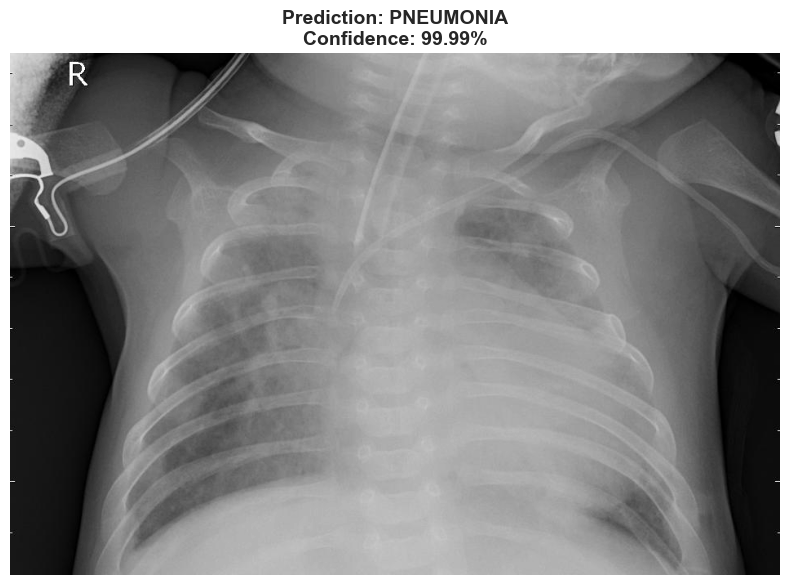

In [44]:
# Predict on a single test image
# Replace with actual test image path
test_image_path = "../data/raw/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"

if os.path.exists(test_image_path):
    prediction, confidence, probs = predict_single_image(test_image_path)
    
    # Visualize the prediction
    img = Image.open(test_image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray')
    plt.title(f'Prediction: {prediction}\nConfidence: {confidence:.2f}%', 
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('../results/plots/single_prediction.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Test image not found. Please provide a valid path.")

In [46]:
# Batch prediction example
# Predict on multiple images from test set
test_images = [
    "../data/raw/chest_xray/test/NORMAL/IM-0067-0001.jpeg",
    "../data/raw/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg",
    # Add more paths as needed
]

# Filter existing paths
existing_paths = [p for p in test_images if os.path.exists(p)]

if existing_paths:
    results = predictor.predict_batch(existing_paths)
    
    # Display results
    print("\n" + "="*60)
    print("BATCH PREDICTION RESULTS")
    print("="*60)
    for result in results:
        print(f"\nImage: {os.path.basename(result['image_path'])}")
        print(f"Prediction: {result['prediction']}")
        print(f"Confidence: {result['confidence']:.2f}%")
        print(f"Probabilities: {result['probabilities']}")
    print("="*60)


Processing 2 images...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.42it/s]


BATCH PREDICTION RESULTS

Image: IM-0067-0001.jpeg
Prediction: NORMAL
Confidence: 99.86%
Probabilities: {'NORMAL': 99.86227750778198, 'PNEUMONIA': 0.1377203967422247}

Image: person1_virus_6.jpeg
Prediction: PNEUMONIA
Confidence: 99.99%
Probabilities: {'NORMAL': 0.006210910942172632, 'PNEUMONIA': 99.9937891960144}


Performance Analysis


High Confidence (>0.9) Predictions:
  Count: 401
  Accuracy: 91.27%

Low Confidence (<=0.9) Predictions:
  Count: 223
  Accuracy: 87.89%


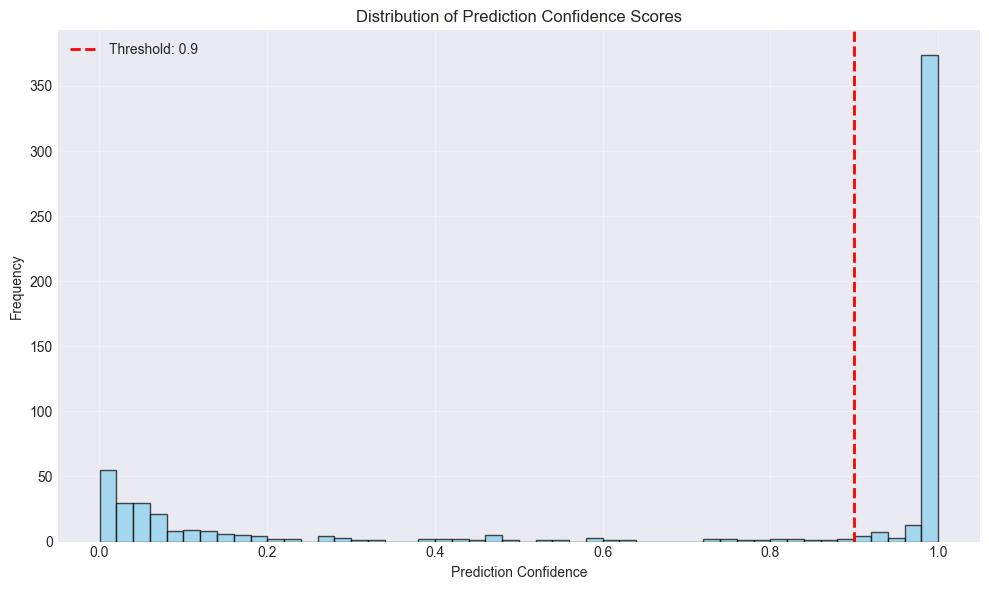

In [49]:
# Analyze predictions by confidence level
def analyze_by_confidence(y_true, y_pred, y_scores, threshold=0.9):
    """Analyze predictions by confidence level"""
    high_conf_mask = y_scores > threshold
    low_conf_mask = y_scores <= threshold
    
    if high_conf_mask.any():
        high_conf_acc = (y_true[high_conf_mask] == y_pred[high_conf_mask]).mean()
        print(f"\nHigh Confidence (>{threshold}) Predictions:")
        print(f"  Count: {high_conf_mask.sum()}")
        print(f"  Accuracy: {high_conf_acc*100:.2f}%")
    
    if low_conf_mask.any():
        low_conf_acc = (y_true[low_conf_mask] == y_pred[low_conf_mask]).mean()
        print(f"\nLow Confidence (<={threshold}) Predictions:")
        print(f"  Count: {low_conf_mask.sum()}")
        print(f"  Accuracy: {low_conf_acc*100:.2f}%")
    
    # Plot confidence distribution
    plt.figure(figsize=(10, 6))
    plt.hist(y_scores, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold: {threshold}')
    plt.xlabel('Prediction Confidence')
    plt.ylabel('Frequency')
    plt.title('Distribution of Prediction Confidence Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results/plots/confidence_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

analyze_by_confidence(y_true, y_pred, y_scores)


Error Analysis:
False Positives: 47 (20.09% of Normal cases)
False Negatives: 15 (3.85% of Pneumonia cases)


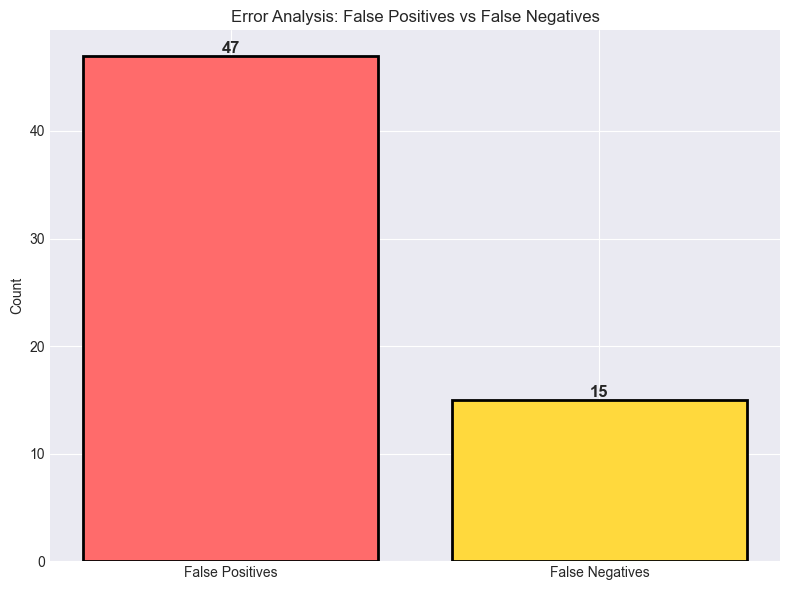

In [51]:
# Error analysis by class
def error_analysis(y_true, y_pred):
    """Detailed error analysis"""
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y_true, y_pred)
    
    print("\nError Analysis:")
    print("="*60)
    
    # False Positives (Normal predicted as Pneumonia)
    fp = cm[0, 1]
    total_normal = cm[0].sum()
    fp_rate = (fp / total_normal) * 100 if total_normal > 0 else 0
    print(f"False Positives: {fp} ({fp_rate:.2f}% of Normal cases)")
    
    # False Negatives (Pneumonia predicted as Normal)
    fn = cm[1, 0]
    total_pneumonia = cm[1].sum()
    fn_rate = (fn / total_pneumonia) * 100 if total_pneumonia > 0 else 0
    print(f"False Negatives: {fn} ({fn_rate:.2f}% of Pneumonia cases)")
    
    print("="*60)
    
    # Visualize
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    categories = ['False Positives', 'False Negatives']
    counts = [fp, fn]
    colors = ['#ff6b6b', '#ffd93d']
    
    bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=2)
    ax.set_ylabel('Count')
    ax.set_title('Error Analysis: False Positives vs False Negatives')
    
    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../results/plots/error_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

error_analysis(y_true, y_pred)

Model Inference Speed Benchmark

In [56]:
# Benchmark inference speed
from inference import benchmark_inference_speed

# Use a test image
test_image = "../data/raw/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

if os.path.exists(test_image):
    benchmark_inference_speed(predictor, test_image, num_iterations=100)
else:
    print("Test image not found for benchmarking")


Benchmarking inference speed (100 iterations)...


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.18it/s]


INFERENCE SPEED BENCHMARK
Total Time: 9.83 seconds
Average Time per Image: 98.27 ms
Throughput: 10.18 images/second



Save Final Results Summary

In [59]:
# Create comprehensive results summary
summary = {
    'Model': 'EfficientNet-B0',
    'Dataset': 'Chest X-Ray Pneumonia',
    'Training Samples': len(train_loader.dataset),
    'Validation Samples': len(val_loader.dataset),
    'Test Samples': len(test_loader.dataset),
    'Best Validation Accuracy': f"{max(history['val_acc']):.2f}%",
    'Test Accuracy': f"{metrics['accuracy']*100:.2f}%",
    'Test Precision': f"{metrics['precision']*100:.2f}%",
    'Test Recall': f"{metrics['recall']*100:.2f}%",
    'Test F1-Score': f"{metrics['f1_score']*100:.2f}%",
    'Device': str(Config.DEVICE),
    'Training Epochs': len(history['train_loss']),
}

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
for key, value in summary.items():
    print(f"{key:.<30} {value}")
print("="*60)


FINAL RESULTS SUMMARY
Model......................... EfficientNet-B0
Dataset....................... Chest X-Ray Pneumonia
Training Samples.............. 5216
Validation Samples............ 16
Test Samples.................. 624
Best Validation Accuracy...... 100.00%
Test Accuracy................. 90.06%
Test Precision................ 88.86%
Test Recall................... 96.15%
Test F1-Score................. 92.36%
Device........................ cuda
Training Epochs............... 11


In [61]:
# Save to file
import json
with open('../results/metrics/final_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("\n✓ Summary saved to results/metrics/final_summary.json")


✓ Summary saved to results/metrics/final_summary.json


Export Model for Production

In [64]:
# 1. Save complete model
torch.save(model, '../models/saved_models/complete_model.pth')
print("✓ Complete model saved")

✓ Complete model saved


In [66]:
# 2. Save model for inference (state dict only)
torch.save(model.state_dict(), '../models/saved_models/model_weights.pth')
print("✓ Model weights saved")

✓ Model weights saved


In [68]:
# 3. Export to ONNX (optional - for deployment)
try:
    dummy_input = torch.randn(1, 3, 224, 224).to(Config.DEVICE)
    torch.onnx.export(
        model,
        dummy_input,
        '../models/saved_models/model.onnx',
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
    )
    print("✓ ONNX model exported")
except Exception as e:
    print(f"ONNX export failed: {e}")

print("\n" + "="*60)
print("MODEL EXPORT COMPLETE")
print("="*60)
print("Models saved in: models/saved_models/")
print("  - best_model.pth (checkpoint with optimizer)")
print("  - complete_model.pth (full model)")
print("  - model_weights.pth (weights only)")
print("  - model.onnx (ONNX format)")
print("="*60)

C:\Users\Jainish\AppData\Local\Temp\ipykernel_6804\2086769106.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


ONNX export failed: Module onnx is not installed!

MODEL EXPORT COMPLETE
Models saved in: models/saved_models/
  - best_model.pth (checkpoint with optimizer)
  - complete_model.pth (full model)
  - model_weights.pth (weights only)
  - model.onnx (ONNX format)
